 All libraries loaded successfully!


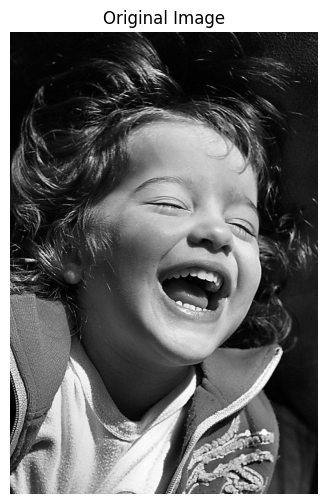

26-06-19 20:39:27 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to C:\Users\malik\.deepface\weights\facial_expression_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: C:\Users\malik\.deepface\weights\facial_expression_model_weights.h5
100%|██████████| 5.98M/5.98M [00:04<00:00, 1.29MB/s]


 Dominant Emotion : SAD

 All Emotion Scores:
  angry       0.0%
  disgust     0.0%
  fear        0.0%
  happy       0.0%
  sad        ███████████████████ 95.6%
  surprise    0.0%
  neutral     4.4%


In [ ]:
import cv2
from deepface import DeepFace
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── mappings ──────────────────────────────────────────
color_map = {
    'happy'   : (0, 255, 0),
    'sad'     : (255, 100, 0),
    'angry'   : (0, 0, 255),
    'surprise': (0, 255, 255),
    'neutral' : (200, 200, 200),
    'fear'    : (128, 0, 128),
    'disgust' : (0, 128, 0),
}

emoji_map = {
    'happy'   : 'HAPPY   :)',
    'sad'     : 'SAD     :(',
    'angry'   : 'ANGRY   >:(',
    'surprise': 'SURPRISE :O',
    'neutral' : 'NEUTRAL  :|',
    'fear'    : 'FEAR    D:',
    'disgust' : 'DISGUST  ew',
}

# ── smoothing buffer ──────────────────────────────────
BUFFER_SIZE  = 10   # collect 10 predictions → pick most common
emotion_buffer = []
stable_emotion = "neutral"
stable_color   = (200, 200, 200)

face_box = (0, 0, 0, 0)  # remember last face position

# ── webcam ────────────────────────────────────────────
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

frame_count = 0
ANALYZE_EVERY = 4   # analyze 1 out of every 4 frames

print("Camera ON — press Q to quit")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    # ── analyze every Nth frame only ──────────────────
    if frame_count % ANALYZE_EVERY == 0:
        try:
            result = DeepFace.analyze(
                frame,
                actions      = ['emotion'],
                enforce_detection = False,
                silent       = True
            )

            emo = result[0]['dominant_emotion']
            r   = result[0]['region']
            face_box = (r['x'], r['y'], r['w'], r['h'])

            # add to buffer
            emotion_buffer.append(emo)
            if len(emotion_buffer) > BUFFER_SIZE:
                emotion_buffer.pop(0)      # remove oldest

            # pick the MOST COMMON emotion in buffer
            stable_emotion = Counter(emotion_buffer).most_common(1)[0][0]
            stable_color   = color_map.get(stable_emotion, (255,255,255))

        except:
            pass   # if no face → keep showing last result

    # ── draw everything ───────────────────────────────
    x, y, w, h = face_box

    if w > 0:
        # face rectangle
        cv2.rectangle(frame, (x, y), (x+w, y+h), stable_color, 3)

        # emotion label above box
        label = emoji_map.get(stable_emotion, stable_emotion)
        cv2.putText(frame, label,
                    (x, y - 15),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1.1, stable_color, 2)

    # ── buffer progress bar (shows stability) ─────────
    filled = len(emotion_buffer)
    bar_w  = int((filled / BUFFER_SIZE) * 200)
    cv2.rectangle(frame, (10, 450), (210, 470), (50,50,50), -1)
    cv2.rectangle(frame, (10, 450), (10 + bar_w, 470), (0,255,0), -1)
    cv2.putText(frame, f"Stability: {filled}/{BUFFER_SIZE}",
                (10, 445),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55, (255,255,255), 1)

    # ── current stable emotion bottom center ──────────
    cv2.putText(frame,
                f"Emotion: {stable_emotion.upper()}",
                (180, 460),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8, stable_color, 2)

    cv2.imshow("Live Emotion Detector  |  Q = quit", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("Done!")